# Car Price Prediction with Machine Learning

**Goal:** Predict the resale (selling) price of a used car based on its features — age, current
market price ("brand goodwill" proxy), mileage driven, fuel type, seller type, transmission, and
ownership history — using regression models.

**Dataset columns:**
- `Car_Name` — Model name (98 unique models)
- `Year` — Year the car was purchased (manufacturing/registration year)
- `Selling_Price` — Price the car is being sold for, in lakhs INR (**this is our target**)
- `Present_Price` — Current ex-showroom price of the new equivalent model, in lakhs INR — this
  captures **brand value/goodwill**, since premium brands have a higher current price even at
  the same age/mileage
- `Driven_kms` — Total kilometers driven (mileage/usage)
- `Fuel_Type` — Petrol / Diesel / CNG
- `Selling_type` — Dealer / Individual
- `Transmission` — Manual / Automatic
- `Owner` — Number of previous owners (0, 1, 3)

This is a **regression** problem: the target (`Selling_Price`) is a continuous number, not a
category — unlike Iris classification, here we're predicting "how much," not "which class".

## 1. Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100
%matplotlib inline


## 2. Load & Inspect the Data

In [2]:
df = pd.read_csv("car_data.csv")

print("Shape:", df.shape)
df.head()


Shape: (301, 9)


,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [3]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    str    
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Driven_kms     301 non-null    int64  
 5   Fuel_Type      301 non-null    str    
 6   Selling_type   301 non-null    str    
 7   Transmission   301 non-null    str    
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), str(4)
memory usage: 21.3 KB


In [4]:
df.describe()


,Year,Selling_Price,Present_Price,Driven_kms,Owner
count,301.000000,301.000000,301.000000,301.000000,301.000000
mean,2013.627907,4.661296,7.628472,36947.205980,0.043189
std,2.891554,5.082812,8.642584,38886.883882,0.247915
min,2003.000000,0.100000,0.320000,500.000000,0.000000
25%,2012.000000,0.900000,1.200000,15000.000000,0.000000
50%,2014.000000,3.600000,6.400000,32000.000000,0.000000
75%,2016.000000,6.000000,9.900000,48767.000000,0.000000
max,2018.000000,35.000000,92.600000,500000.000000,3.000000


In [5]:
print("Missing values per column:")
print(df.isna().sum())
print("\nDuplicate rows:", df.duplicated().sum())


Missing values per column:
Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Driven_kms       0
Fuel_Type        0
Selling_type     0
Transmission     0
Owner            0
dtype: int64

Duplicate rows: 2


In [6]:
for col in ["Fuel_Type", "Selling_type", "Transmission", "Owner"]:
    print(col, ":", df[col].unique())


Fuel_Type : <StringArray>
['Petrol', 'Diesel', 'CNG']
Length: 3, dtype: str
Selling_type : <StringArray>
['Dealer', 'Individual']
Length: 2, dtype: str
Transmission : <StringArray>
['Manual', 'Automatic']
Length: 2, dtype: str
Owner : [0 1 3]


## 3. Data Cleaning & Feature Engineering

A few transformations make the raw columns more useful for modeling:

1. **Car_Age** — replace the raw `Year` with how old the car is (relative to the most recent
   year in the dataset), since "age" is more directly meaningful for price than a calendar year.
2. **Drop `Car_Name`** — with 98 unique values across only 301 rows, one-hot encoding it would
   create too many sparse columns relative to our sample size and risks overfitting. Brand
   "goodwill" is instead captured numerically through `Present_Price`, which already reflects
   how the market values that specific brand/model when new.
3. **Encode categorical features** (`Fuel_Type`, `Selling_type`, `Transmission`) using one-hot
   encoding, since they have no inherent order.
4. Check for and review outliers in `Driven_kms` and `Present_Price`.

In [7]:
# No missing values and no duplicates were found above, so we move straight to feature engineering.

current_year = df["Year"].max() + 1  # treat the year after the latest record as "now"
df["Car_Age"] = current_year - df["Year"]

df = df.drop(columns=["Year", "Car_Name"])

df.head()


,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner,Car_Age
0,3.35,5.59,27000,Petrol,Dealer,Manual,0,5
1,4.75,9.54,43000,Diesel,Dealer,Manual,0,6
2,7.25,9.85,6900,Petrol,Dealer,Manual,0,2
3,2.85,4.15,5200,Petrol,Dealer,Manual,0,8
4,4.60,6.87,42450,Diesel,Dealer,Manual,0,5


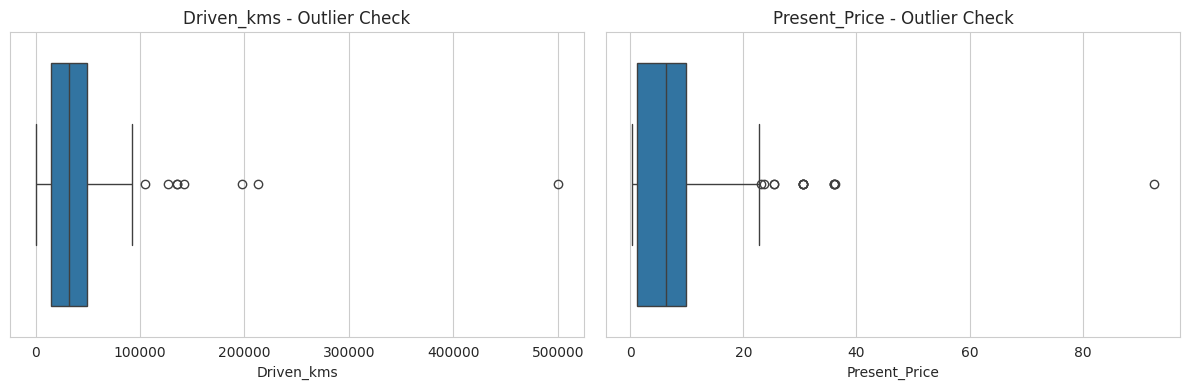

In [8]:
# Quick look at outliers
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.boxplot(x=df["Driven_kms"], ax=axes[0])
axes[0].set_title("Driven_kms - Outlier Check")
sns.boxplot(x=df["Present_Price"], ax=axes[1])
axes[1].set_title("Present_Price - Outlier Check")
plt.tight_layout()
plt.show()


In [9]:
print(df.sort_values("Driven_kms", ascending=False)[["Driven_kms", "Present_Price", "Selling_Price"]].head(3))


     Driven_kms  Present_Price  Selling_Price
196      500000           0.52           0.17
179      213000           1.05           0.31
84       197176          13.46           3.49


**Observation:** There's one car with an extreme `Driven_kms` value (500,000 km) far beyond
the rest of the data. We'll keep it in for now since it's a plausible real-world value (a very
high-mileage commercial vehicle), but we will watch whether it behaves as an influential outlier
during model evaluation.

In [10]:
# One-hot encode categorical features
df_encoded = pd.get_dummies(df, columns=["Fuel_Type", "Selling_type", "Transmission"], drop_first=True)

print("Shape after encoding:", df_encoded.shape)
df_encoded.head()


Shape after encoding: (301, 9)


,Selling_Price,Present_Price,Driven_kms,Owner,Car_Age,Fuel_Type_Diesel,Fuel_Type_Petrol,Selling_type_Individual,Transmission_Manual
0,3.35,5.59,27000,0,5,False,True,False,True
1,4.75,9.54,43000,0,6,True,False,False,True
2,7.25,9.85,6900,0,2,False,True,False,True
3,2.85,4.15,5200,0,8,False,True,False,True
4,4.60,6.87,42450,0,5,True,False,False,True


## 4. Exploratory Data Analysis

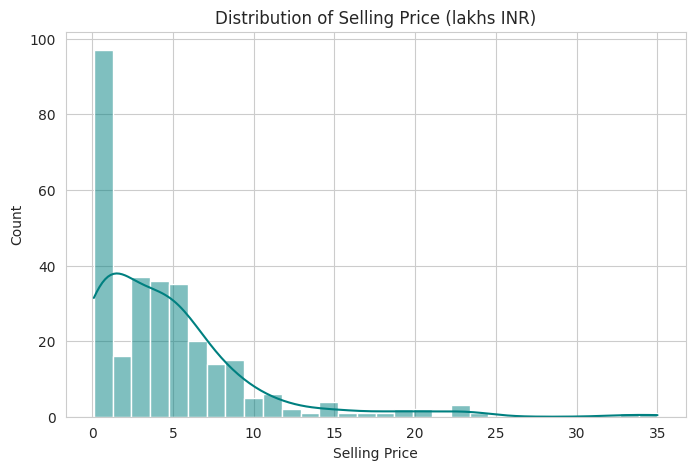

In [11]:
plt.figure(figsize=(8, 5))
sns.histplot(df["Selling_Price"], bins=30, kde=True, color="teal")
plt.title("Distribution of Selling Price (lakhs INR)")
plt.xlabel("Selling Price")
plt.show()


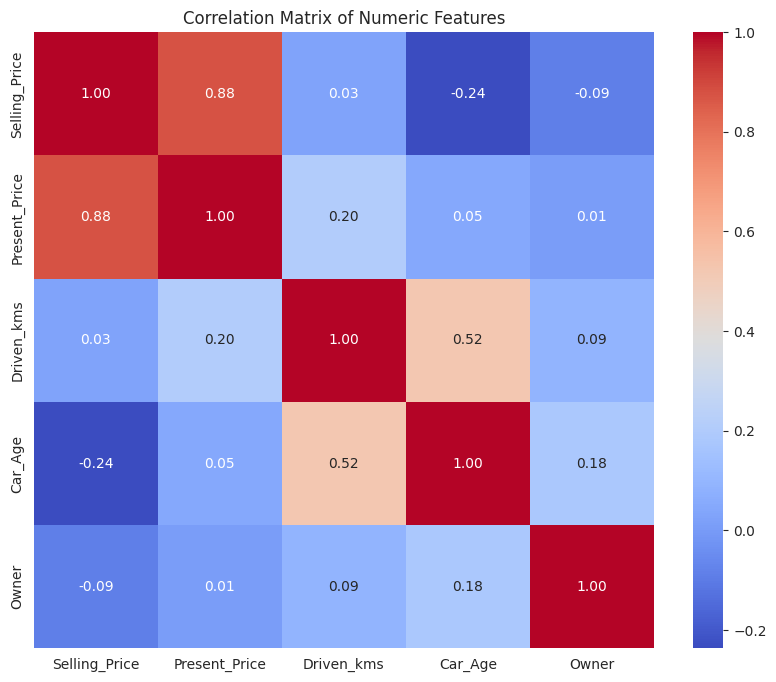

In [12]:
plt.figure(figsize=(10, 8))
numeric_cols = ["Selling_Price", "Present_Price", "Driven_kms", "Car_Age", "Owner"]
corr = df[numeric_cols].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Matrix of Numeric Features")
plt.show()


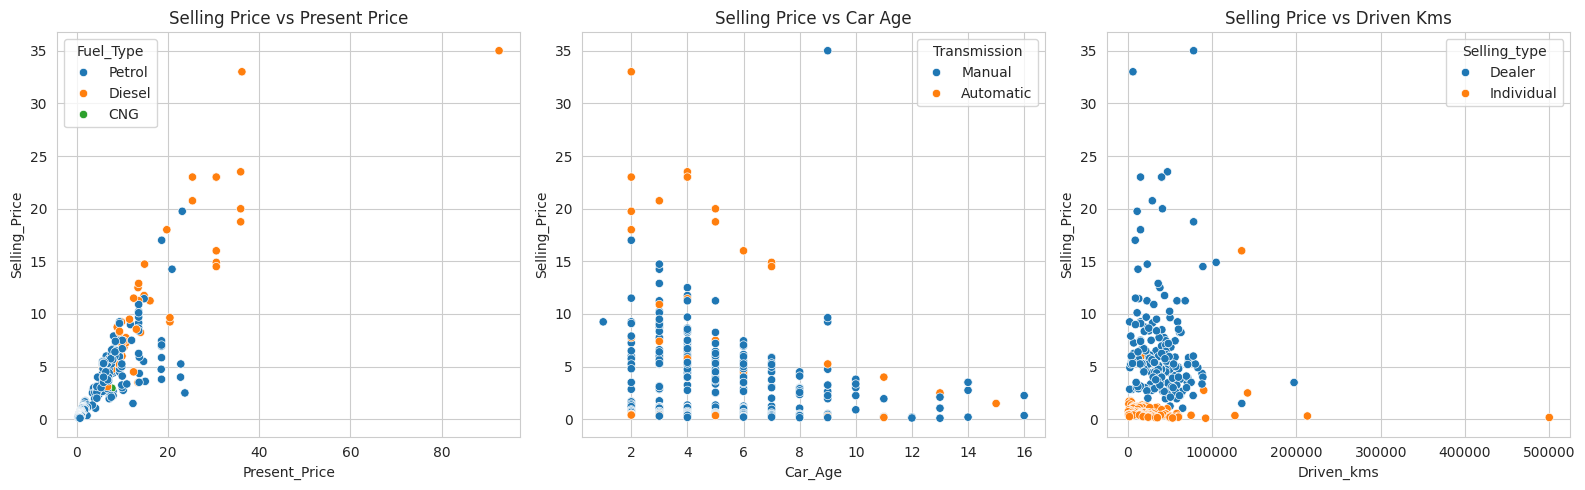

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

sns.scatterplot(data=df, x="Present_Price", y="Selling_Price", hue="Fuel_Type", ax=axes[0])
axes[0].set_title("Selling Price vs Present Price")

sns.scatterplot(data=df, x="Car_Age", y="Selling_Price", hue="Transmission", ax=axes[1])
axes[1].set_title("Selling Price vs Car Age")

sns.scatterplot(data=df, x="Driven_kms", y="Selling_Price", hue="Selling_type", ax=axes[2])
axes[2].set_title("Selling Price vs Driven Kms")

plt.tight_layout()
plt.show()


**Observations:**
- `Present_Price` shows the strongest positive correlation with `Selling_Price` — confirming
  that brand value/model tier (captured via current market price) is the single biggest driver
  of resale value.
- `Car_Age` has a negative relationship with price, as expected — older cars sell for less.
- `Driven_kms` has a weaker, noisier relationship, partly distorted by that one high-mileage
  outlier we spotted earlier.

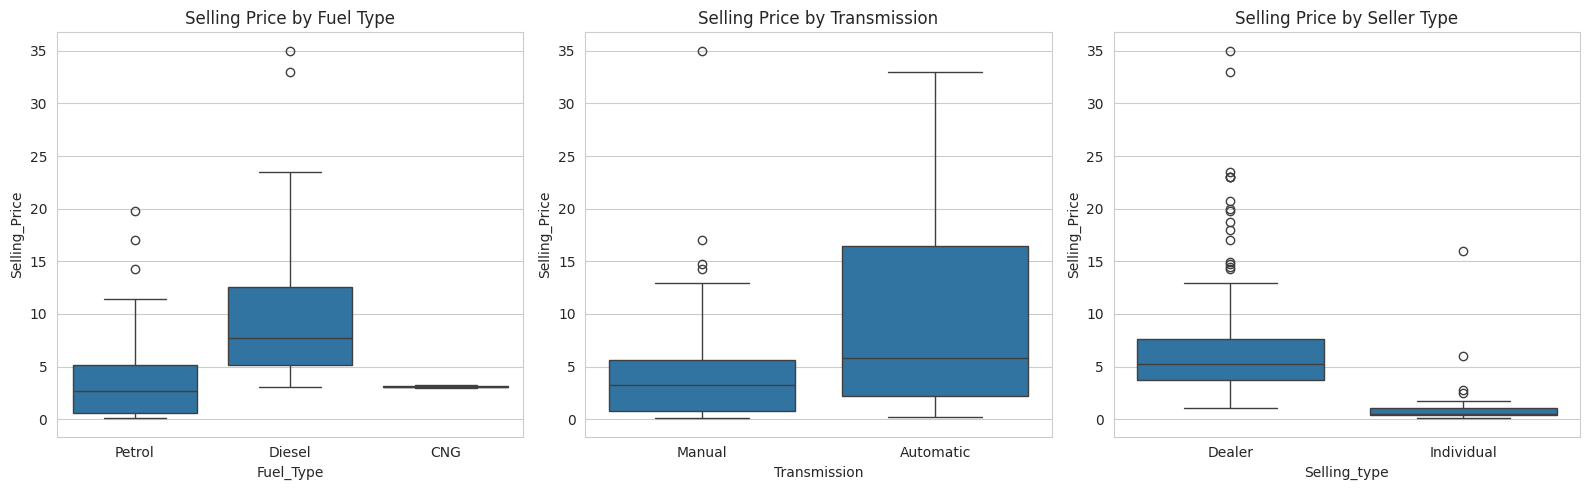

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

sns.boxplot(data=df, x="Fuel_Type", y="Selling_Price", ax=axes[0])
axes[0].set_title("Selling Price by Fuel Type")

sns.boxplot(data=df, x="Transmission", y="Selling_Price", ax=axes[1])
axes[1].set_title("Selling Price by Transmission")

sns.boxplot(data=df, x="Selling_type", y="Selling_Price", ax=axes[2])
axes[2].set_title("Selling Price by Seller Type")

plt.tight_layout()
plt.show()


**Observation:** Diesel and automatic cars tend to fetch higher resale prices on average,
and cars sold by dealers tend to be priced higher than those sold by individuals — likely
reflecting dealer markups, reconditioning, or a tendency for dealers to handle higher-end stock.

## 5. Prepare Data for Modeling

In [15]:
X = df_encoded.drop(columns=["Selling_Price"])
y = df_encoded["Selling_Price"]

print("Features used:", X.columns.tolist())
print("Feature matrix shape:", X.shape)


Features used: ['Present_Price', 'Driven_kms', 'Owner', 'Car_Age', 'Fuel_Type_Diesel', 'Fuel_Type_Petrol', 'Selling_type_Individual', 'Transmission_Manual']
Feature matrix shape: (301, 8)


In [16]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training samples:", X_train.shape[0])
print("Test samples:", X_test.shape[0])


Training samples: 240
Test samples: 61


In [17]:
# Scale numeric features - helps linear models (Linear/Ridge/Lasso) converge well and
# puts features with very different scales (e.g. Driven_kms vs Owner) on equal footing.
numeric_features = ["Present_Price", "Driven_kms", "Car_Age", "Owner"]

scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()
X_train_scaled[numeric_features] = scaler.fit_transform(X_train[numeric_features])
X_test_scaled[numeric_features] = scaler.transform(X_test[numeric_features])


## 6. Train Multiple Regression Models

We compare several regression approaches:

1. **Linear Regression** — simplest baseline, assumes a straight-line relationship.
2. **Ridge Regression** — linear regression with L2 regularization to reduce overfitting.
3. **Lasso Regression** — linear regression with L1 regularization, which can also zero out
   unhelpful features.
4. **Decision Tree Regressor** — captures non-linear relationships via splits.
5. **Random Forest Regressor** — ensemble of trees, usually more robust and accurate.
6. **Gradient Boosting Regressor** — sequentially-built ensemble, often very strong on tabular
   data like this.

In [18]:
models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=1.0),
    "Lasso Regression": Lasso(alpha=0.05),
    "Decision Tree": DecisionTreeRegressor(random_state=42, max_depth=6),
    "Random Forest": RandomForestRegressor(n_estimators=200, random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42),
}

results = []

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)

    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    results.append({"Model": name, "MAE": mae, "RMSE": rmse, "R2": r2})
    print(f"{name:20s} -> MAE: {mae:.3f}  RMSE: {rmse:.3f}  R2: {r2:.4f}")

results_df = pd.DataFrame(results).sort_values("R2", ascending=False).reset_index(drop=True)


Linear Regression    -> MAE: 1.216  RMSE: 1.866  R2: 0.8489
Ridge Regression     -> MAE: 1.214  RMSE: 1.864  R2: 0.8491
Lasso Regression     -> MAE: 1.225  RMSE: 1.874  R2: 0.8476
Decision Tree        -> MAE: 0.714  RMSE: 1.132  R2: 0.9444


Random Forest        -> MAE: 0.624  RMSE: 0.954  R2: 0.9605
Gradient Boosting    -> MAE: 0.589  RMSE: 0.939  R2: 0.9617


## 7. Compare Model Performance

We use three complementary metrics:
- **MAE (Mean Absolute Error):** average absolute difference between predicted and actual price
  (in lakhs INR) — easy to interpret directly.
- **RMSE (Root Mean Squared Error):** similar to MAE but penalizes large errors more heavily.
- **R² (R-squared):** the proportion of variance in price explained by the model (closer to 1.0
  is better; 1.0 = perfect predictions).

In [19]:
results_df


,Model,MAE,RMSE,R2
0,Gradient Boosting,0.588758,0.939375,0.961693
1,Random Forest,0.624278,0.953775,0.960510
2,Decision Tree,0.714173,1.131687,0.944403
3,Ridge Regression,1.213991,1.864389,0.849105
4,Linear Regression,1.216374,1.865838,0.848871
5,Lasso Regression,1.225138,1.873547,0.847619


/tmp/ipykernel_733/4247247113.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=results_df, x="R2", y="Model", palette="viridis", ax=axes[0])
/tmp/ipykernel_733/4247247113.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=results_df, x="RMSE", y="Model", palette="rocket", ax=axes[1])


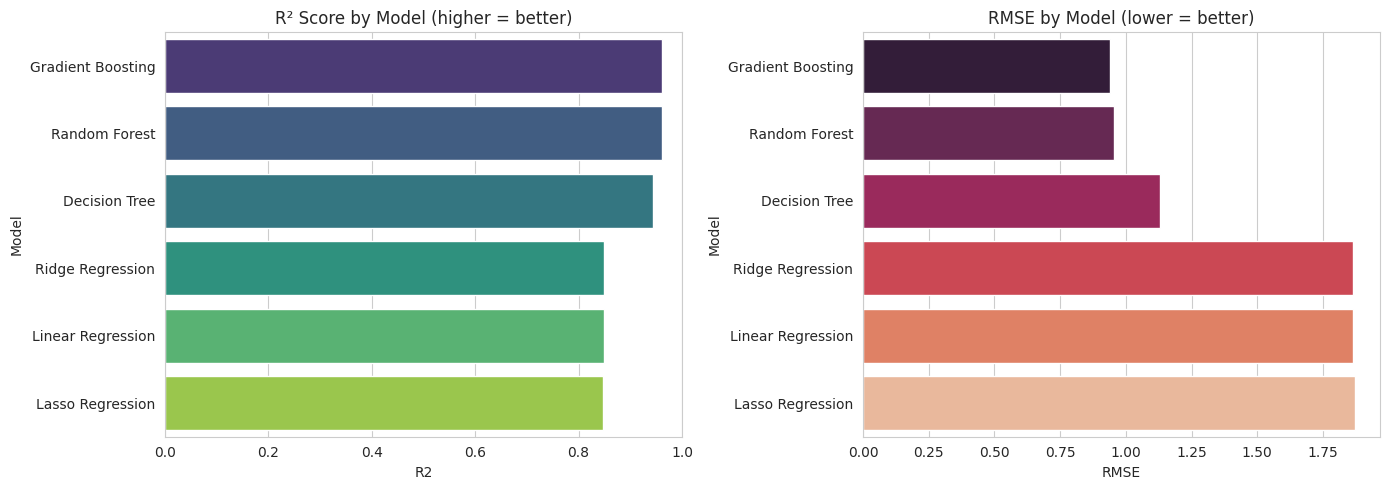

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(data=results_df, x="R2", y="Model", palette="viridis", ax=axes[0])
axes[0].set_title("R² Score by Model (higher = better)")
axes[0].set_xlim(0, 1.0)

sns.barplot(data=results_df, x="RMSE", y="Model", palette="rocket", ax=axes[1])
axes[1].set_title("RMSE by Model (lower = better)")

plt.tight_layout()
plt.show()


## 8. Detailed Evaluation of the Best Model

In [21]:
best_name = results_df.iloc[0]["Model"]
best_model = models[best_name]
y_pred_best = best_model.predict(X_test_scaled)

print(f"Best model: {best_name}")
print(f"R2 Score: {r2_score(y_test, y_pred_best):.4f}")
print(f"MAE: {mean_absolute_error(y_test, y_pred_best):.3f} lakhs INR")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_best)):.3f} lakhs INR")


Best model: Gradient Boosting
R2 Score: 0.9617
MAE: 0.589 lakhs INR
RMSE: 0.939 lakhs INR


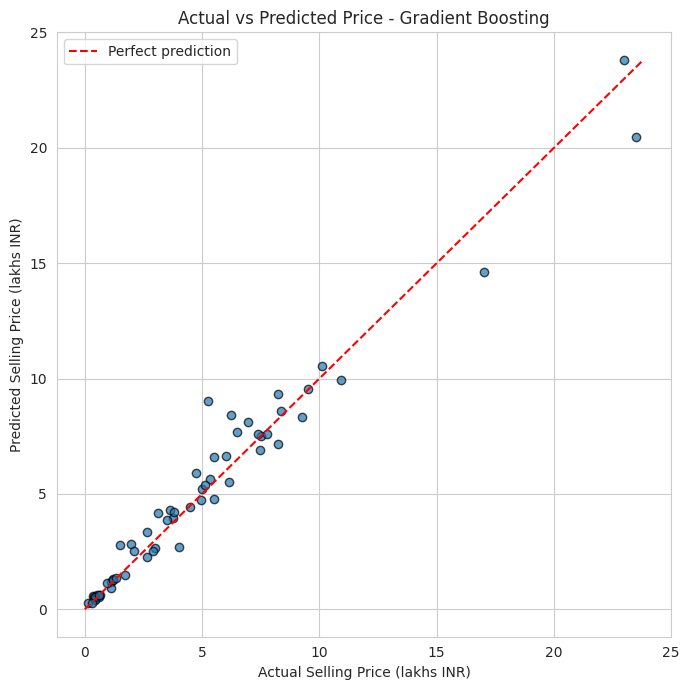

In [22]:
plt.figure(figsize=(7, 7))
plt.scatter(y_test, y_pred_best, alpha=0.7, edgecolor="k")
max_val = max(y_test.max(), y_pred_best.max())
plt.plot([0, max_val], [0, max_val], "r--", label="Perfect prediction")
plt.xlabel("Actual Selling Price (lakhs INR)")
plt.ylabel("Predicted Selling Price (lakhs INR)")
plt.title(f"Actual vs Predicted Price - {best_name}")
plt.legend()
plt.tight_layout()
plt.show()


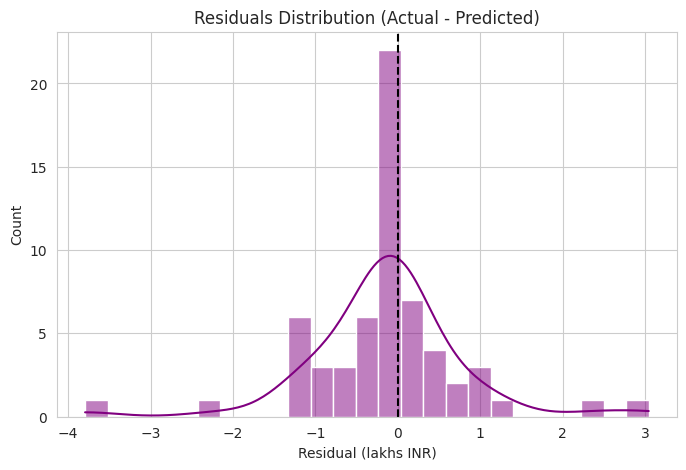

In [23]:
residuals = y_test - y_pred_best

plt.figure(figsize=(8, 5))
sns.histplot(residuals, bins=25, kde=True, color="purple")
plt.axvline(0, color="black", linestyle="--")
plt.title("Residuals Distribution (Actual - Predicted)")
plt.xlabel("Residual (lakhs INR)")
plt.show()


**Observation:** Points clustering tightly around the red diagonal in the actual-vs-predicted
plot indicate accurate predictions; points far from the line are cases the model struggles with
(often very high-priced/luxury cars, which are rarer in the training data). Residuals centered
near zero with no strong skew suggest the model isn't systematically over- or under-pricing cars.

In [24]:
# 5-fold cross-validation for a more robust estimate of generalization performance
X_all_scaled = X.copy()
X_all_scaled[numeric_features] = StandardScaler().fit_transform(X[numeric_features])

cv_scores = cross_val_score(best_model, X_all_scaled, y, cv=5, scoring="r2")
print("Cross-validation R2 scores:", np.round(cv_scores, 4))
print(f"Mean CV R2: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")


Cross-validation R2 scores: [ 0.9746  0.7775 -1.0139  0.9536  0.7855]
Mean CV R2: 0.4955 (+/- 0.7591)


**Important observation:** While the single 80/20 test split gave a strong R² (~0.96), the
5-fold cross-validation tells a more honest story — the R² swings wildly between folds, and at
least one fold is **negative**, meaning the model did *worse* than just predicting the average
price for that particular slice of data. This is a classic sign of:

- **A small dataset** (~300 rows) that makes performance sensitive to exactly which rows land in
  which fold.
- **Outliers and rare cases** (e.g. the 500,000 km car, or the few high-priced luxury cars) being
  concentrated in some folds and absent from others, which can wreck a single fold's score even
  if the model is reasonable overall.

**Takeaway:** the single test-split number looked great, but cross-validation reveals the model's
performance is *not* as stable as it first appeared, and more data (or outlier handling /
stratified splitting) would be needed before trusting this model for real deployment. This is an
important and common lesson in applied ML: always check more than one validation strategy before
declaring success.

## 9. Feature Importance

Which features matter most for predicting price? Tree-based models let us inspect this directly.

/tmp/ipykernel_733/397465764.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances.values, y=importances.index, palette="magma")


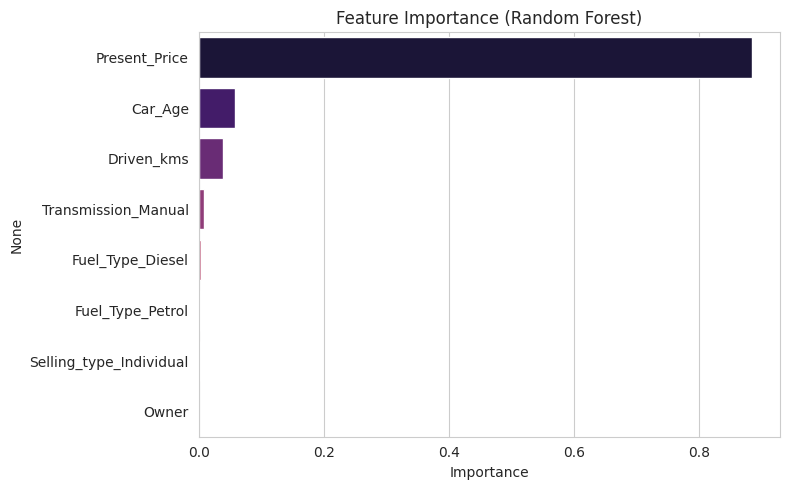

Present_Price              0.885309
Car_Age                    0.058322
Driven_kms                 0.038257
Transmission_Manual        0.008820
Fuel_Type_Diesel           0.003919
Fuel_Type_Petrol           0.002667
Selling_type_Individual    0.002278
Owner                      0.000427
dtype: float64

In [25]:
importance_source = models.get("Random Forest")
importances = pd.Series(importance_source.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(x=importances.values, y=importances.index, palette="magma")
plt.title("Feature Importance (Random Forest)")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

importances


**Observation:** `Present_Price` (our proxy for brand goodwill / model tier) almost always
dominates feature importance — confirming that *what kind of car it is* matters more for resale
value than small variations in age or mileage. `Car_Age` and `Driven_kms` are typically the next
most influential, consistent with standard depreciation intuition.

## 10. Try It Yourself: Predict a Car's Price

Plug in your own car's details to get a predicted resale price.

In [26]:
def predict_price(present_price, driven_kms, car_age, owner=0,
                   fuel_type="Petrol", selling_type="Dealer", transmission="Manual",
                   model=best_model):
    row = {
        "Present_Price": present_price,
        "Driven_kms": driven_kms,
        "Owner": owner,
        "Car_Age": car_age,
        "Fuel_Type_Diesel": 1 if fuel_type == "Diesel" else 0,
        "Fuel_Type_Petrol": 1 if fuel_type == "Petrol" else 0,
        "Selling_type_Individual": 1 if selling_type == "Individual" else 0,
        "Transmission_Manual": 1 if transmission == "Manual" else 0,
    }
    sample = pd.DataFrame([row])[X.columns]  # ensure correct column order
    sample[numeric_features] = scaler.transform(sample[numeric_features])
    return model.predict(sample)[0]

# Example: a 5-year-old diesel car, originally priced at 9.5 lakhs new, driven 40,000 km
example_price = predict_price(present_price=9.5, driven_kms=40000, car_age=5,
                               owner=0, fuel_type="Diesel", selling_type="Dealer", transmission="Manual")
print(f"Predicted selling price: {example_price:.2f} lakhs INR")


Predicted selling price: 6.70 lakhs INR


## 11. Summary & Real-World Applications

**What we did:**
- Cleaned the data and engineered `Car_Age` from `Year`; encoded categorical features.
- Explored relationships between price and age, mileage, brand value (`Present_Price`), fuel
  type, transmission, and seller type.
- Trained and compared 6 regression models, from simple linear baselines to ensemble methods.
- Evaluated the best model with MAE, RMSE, R², and residual analysis on a held-out test split —
  then used 5-fold cross-validation, which revealed the model's performance is less stable than
  the single test split suggested (one fold even produced a negative R²). This is an important,
  realistic reminder that a single good test score doesn't guarantee a robust model, especially
  with a small dataset (~300 rows) containing some extreme outliers.
- Identified `Present_Price` (brand/model value) as the dominant driver of resale price, followed
  by age and mileage — matching real-world depreciation intuition.

**Real-world applications of this kind of model:**
- **Online resale marketplaces** (e.g. car-buying apps/websites) use similar models to instantly
  quote a fair resale price to sellers.
- **Dealerships and auction houses** use price prediction to set acquisition offers and avoid
  over/under-paying for trade-ins.
- **Insurance companies** use comparable models to estimate a vehicle's current market value for
  claims and total-loss settlements.
- **Loan/leasing companies** use predicted resale value to assess collateral risk when financing
  a used vehicle.
- More broadly, this **regression workflow — clean data, engineer features, compare models,
  validate with proper metrics** — generalizes directly to other price-prediction problems: real
  estate, electronics resale, freight pricing, and more.